# 06 — Binary Relevance: un clasificador por emoción

Comparativa de **Random Forest**, **SVM** y **Logistic Regression** con enfoque Binary Relevance.

Pipeline:
```
Texto → TF-IDF → 6 clasificadores independientes (uno por emoción)
```

Usamos `train_augmented.csv` para reducir el desbalance de clases.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report

EMOTION_COLS  = ['anger', 'fear', 'joy', 'sadness', 'surprise', 'hope']
TRAIN_PATH    = '../train/train_augmented.csv'
DEV_PATH      = '../dev/dev.csv'
TEST_PATH     = '../test/test.csv'

def load_split(path):
    df = pd.read_csv(path).dropna(subset=['text']).reset_index(drop=True)
    for col in EMOTION_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)
    return df

train_df = load_split(TRAIN_PATH)
dev_df   = load_split(DEV_PATH)
test_df  = load_split(TEST_PATH)

print(f'Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}')
print('\nDistribución train:')
print(train_df[EMOTION_COLS].sum().sort_values(ascending=False))

Train: 2848 | Dev: 425 | Test: 863

Distribución train:
sadness     1180
fear         343
joy          169
hope         104
anger         52
surprise      49
dtype: int64


In [3]:
# TF-IDF compartido para todos los clasificadores
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigramas y bigramas
    sublinear_tf=True,    # log(tf) en lugar de tf crudo
    min_df=2,
)

X_train = tfidf.fit_transform(train_df['text'])
X_dev   = tfidf.transform(dev_df['text'])
X_test  = tfidf.transform(test_df['text'])

print(f'Vocabulario TF-IDF: {X_train.shape[1]} features')
print(f'X_train: {X_train.shape} | X_dev: {X_dev.shape} | X_test: {X_test.shape}')

Vocabulario TF-IDF: 9557 features
X_train: (2848, 9557) | X_dev: (425, 9557) | X_test: (863, 9557)


In [4]:
# Definición de clasificadores a comparar
CLASSIFIERS = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'SVM': CalibratedClassifierCV(   # CalibratedClassifierCV para obtener probabilidades
        LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
    ),
    'LogisticRegression': LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
    ),
}

print('Clasificadores:', list(CLASSIFIERS.keys()))

Clasificadores: ['RandomForest', 'SVM', 'LogisticRegression']


In [5]:
def find_best_threshold(probs, labels):
    """Busca el umbral que maximiza F1 binario."""
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.10, 0.91, 0.05):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


results = {}  # {clf_name: {emotion: {dev_f1, test_f1, threshold}}}

for clf_name, clf_template in CLASSIFIERS.items():
    print(f'\n{"="*50}')
    print(f'  {clf_name}')
    print(f'{"="*50}')
    results[clf_name] = {}

    all_dev_preds  = np.zeros((len(dev_df),  len(EMOTION_COLS)), dtype=int)
    all_test_preds = np.zeros((len(test_df), len(EMOTION_COLS)), dtype=int)

    for i, emotion in enumerate(EMOTION_COLS):
        import copy
        clf = copy.deepcopy(clf_template)

        y_train = train_df[emotion].values
        y_dev   = dev_df[emotion].values
        y_test  = test_df[emotion].values

        clf.fit(X_train, y_train)

        # Probabilidades para búsqueda de umbral
        dev_probs  = clf.predict_proba(X_dev)[:, 1]
        test_probs = clf.predict_proba(X_test)[:, 1]

        best_t, dev_f1 = find_best_threshold(dev_probs, y_dev)
        test_preds = (test_probs >= best_t).astype(int)
        test_f1    = f1_score(y_test, test_preds, zero_division=0)

        all_dev_preds[:, i]  = (dev_probs  >= best_t).astype(int)
        all_test_preds[:, i] = test_preds

        results[clf_name][emotion] = {
            'threshold': round(best_t, 2),
            'dev_f1':    round(dev_f1, 4),
            'test_f1':   round(test_f1, 4),
        }
        print(f'  {emotion:10s} | umbral={best_t:.2f} | dev F1={dev_f1:.3f} | test F1={test_f1:.3f}')

    # Micro F1 global
    y_dev_all  = dev_df[EMOTION_COLS].values
    y_test_all = test_df[EMOTION_COLS].values
    micro_dev  = f1_score(y_dev_all,  all_dev_preds,  average='micro', zero_division=0)
    micro_test = f1_score(y_test_all, all_test_preds, average='micro', zero_division=0)

    results[clf_name]['_micro_dev']  = round(micro_dev, 4)
    results[clf_name]['_micro_test'] = round(micro_test, 4)
    print(f'  {"─"*45}')
    print(f'  MICRO F1 → dev={micro_dev:.4f} | test={micro_test:.4f}')


  RandomForest
  anger      | umbral=0.10 | dev F1=0.071 | test F1=0.014
  fear       | umbral=0.15 | dev F1=0.349 | test F1=0.214
  joy        | umbral=0.10 | dev F1=0.283 | test F1=0.184
  sadness    | umbral=0.35 | dev F1=0.364 | test F1=0.450
  surprise   | umbral=0.10 | dev F1=0.050 | test F1=0.000
  hope       | umbral=0.10 | dev F1=0.114 | test F1=0.347
  ─────────────────────────────────────────────
  MICRO F1 → dev=0.2759 | test=0.2843

  SVM
  anger      | umbral=0.25 | dev F1=0.074 | test F1=0.000
  fear       | umbral=0.25 | dev F1=0.326 | test F1=0.234
  joy        | umbral=0.15 | dev F1=0.436 | test F1=0.219
  sadness    | umbral=0.50 | dev F1=0.368 | test F1=0.445
  surprise   | umbral=0.50 | dev F1=0.000 | test F1=0.000
  hope       | umbral=0.10 | dev F1=0.202 | test F1=0.346
  ─────────────────────────────────────────────
  MICRO F1 → dev=0.3010 | test=0.3448

  LogisticRegression
  anger      | umbral=0.15 | dev F1=0.264 | test F1=0.159
  fear       | umbral=0.55 | 

In [6]:
# Tabla resumen comparativa
print('\n=== RESUMEN COMPARATIVA ===')
print(f'{"Clasificador":20s} | {"Dev Micro F1":>12} | {"Test Micro F1":>13}')
print('─' * 52)
for clf_name in CLASSIFIERS:
    dev  = results[clf_name]['_micro_dev']
    test = results[clf_name]['_micro_test']
    print(f'{clf_name:20s} | {dev:>12.4f} | {test:>13.4f}')


=== RESUMEN COMPARATIVA ===
Clasificador         | Dev Micro F1 | Test Micro F1
────────────────────────────────────────────────────
RandomForest         |       0.2759 |        0.2843
SVM                  |       0.3010 |        0.3448
LogisticRegression   |       0.3529 |        0.3258


FileNotFoundError: [Errno 2] No such file or directory: '../submissions/binary_relevance_comparison.png'

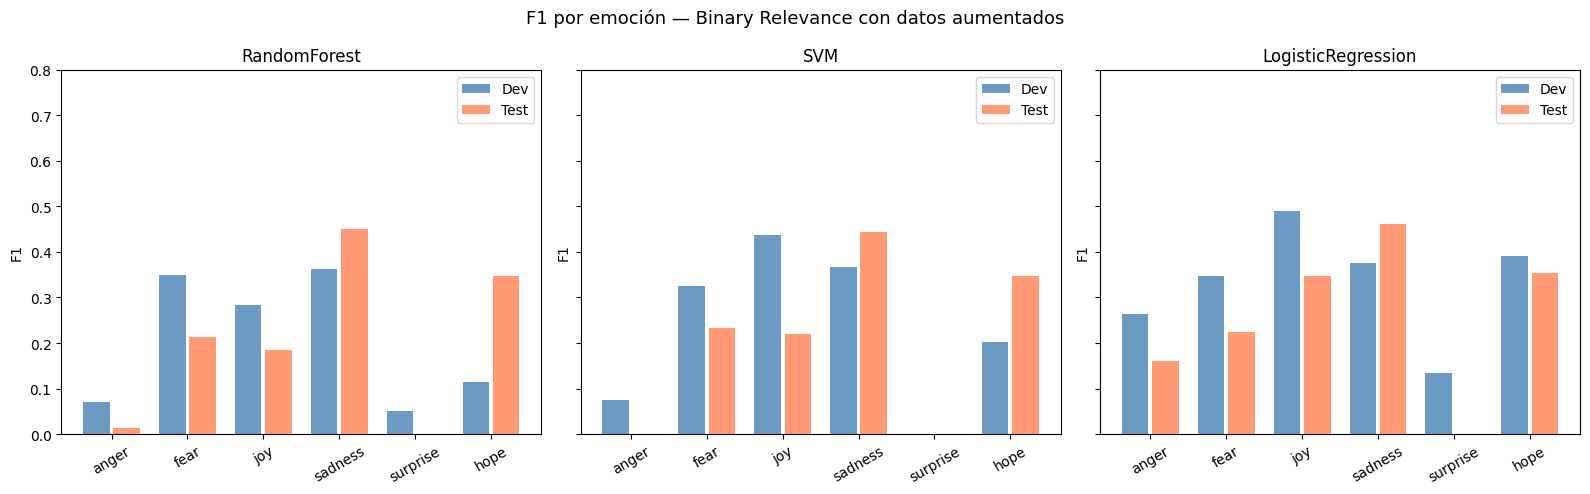

In [7]:
# Gráfica F1 por emoción para cada clasificador
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, clf_name in zip(axes, CLASSIFIERS):
    dev_f1s  = [results[clf_name][e]['dev_f1']  for e in EMOTION_COLS]
    test_f1s = [results[clf_name][e]['test_f1'] for e in EMOTION_COLS]
    x = np.arange(len(EMOTION_COLS))
    ax.bar(x - 0.2, dev_f1s,  0.35, label='Dev',  color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, test_f1s, 0.35, label='Test', color='coral',     alpha=0.8)
    ax.set_title(clf_name)
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTION_COLS, rotation=30)
    ax.set_ylim(0, 0.8)
    ax.legend()
    ax.set_ylabel('F1')

plt.suptitle('F1 por emoción — Binary Relevance con datos aumentados', fontsize=13)
plt.tight_layout()
plt.savefig('../submissions/binary_relevance_comparison.png', dpi=150)
plt.show()

In [9]:
# Top palabras más importantes por emoción (solo RandomForest)
import copy
feature_names = tfidf.get_feature_names_out()

print('=== TOP 10 PALABRAS POR EMOCIÓN (RandomForest) ===')
for emotion in EMOTION_COLS:
    clf = copy.deepcopy(CLASSIFIERS['RandomForest'])
    clf.fit(X_train, train_df[emotion].values)
    top_idx  = clf.feature_importances_.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f'  {emotion:10s}: {" | ".join(top_words)}')

=== TOP 10 PALABRAS POR EMOCIÓN (RandomForest) ===
  anger     : me | de | qué | no | por | vuestra | tiene | cómo | que | vm
  fear      : que | no | de | me | porque | la | mi | dios | en | vm
  joy       : contento | de | que | con | el | tan | lo | me | la | ha
  sadness   : no | que | de | porque | dios | si | lo | me | yo | por
  surprise  : vuestra | vuestra merced | de | qué | merced | que vuestra | es | me | para | que
  hope      : dios | espero | de | esperanza | la | que | vuestra | tener | este | conmigo
